In [1]:
!gdown --id "11rWd5LtSKnmQdHF_EwOGrIDLCtx1OM2B"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=11rWd5LtSKnmQdHF_EwOGrIDLCtx1OM2B
From (redirected): https://drive.google.com/uc?id=11rWd5LtSKnmQdHF_EwOGrIDLCtx1OM2B&confirm=t&uuid=675c661f-6876-4c55-99e1-8acd1d6e2201
To: /kaggle/working/inventory.db
100%|████████████████████████████████████████| 424M/424M [00:05<00:00, 74.5MB/s]


Flagging Vendor Invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with transaction volume.

Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.

An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
conn=sqlite3.connect("inventory.db")

In [4]:
tables=pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",conn)

for table in tables['name']:
  print(f"table name : {table}")
  df=pd.read_sql_query(f"SELECT * FROM {table}",conn)
  display(df.head())

table name : purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name : purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name : vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name : begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name : end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df = pd.read_sql_query("""
  select
  p.PONumber,
  count(distinct p.Brand) as total_brands,
  sum(p.Quantity) as total_item_quantity,
  sum(p.Dollars) as total_item_dollars,
  avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_recieving_delay
  from purchases p
  group by p.PONumber
  
  """,conn)

In [6]:
pd.read_sql_query("""
select
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi

""",conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [7]:
#now we merge both the tables
df=pd.read_sql_query("""
WITH purchase_agg AS (
  SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_recieving_delay
  FROM purchases p
  GROUP BY p.PONumber

)

SELECT
vi.PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_recieving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
ON vi.PONumber = pa.PONumber

""",conn)

In [8]:
#checking if there are any null values
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_recieving_delay    0
dtype: int64

In [9]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_recieving_delay    float64
dtype: object

In [10]:
# now we can aggreaate the clusters and start attaching the labels based on thier patterns
def create_invoice_risk(row):
  #Invoice total mismatch with item-level total
  if(abs(row['invoice_dollars']-row['total_item_dollars'])>5):
    return 1
  #abnormally high recieving delay
  if row['avg_recieving_delay']>10:
    return 1

  return 0

df['flag_invoice']=df.apply(create_invoice_risk,axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

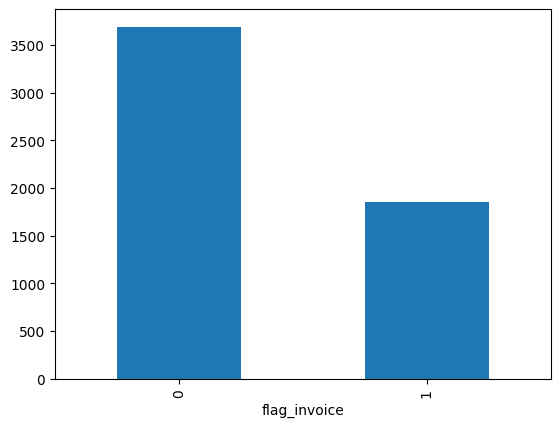

In [11]:
 #data visualization of the counts
 df['flag_invoice'].value_counts().plot(kind='bar')

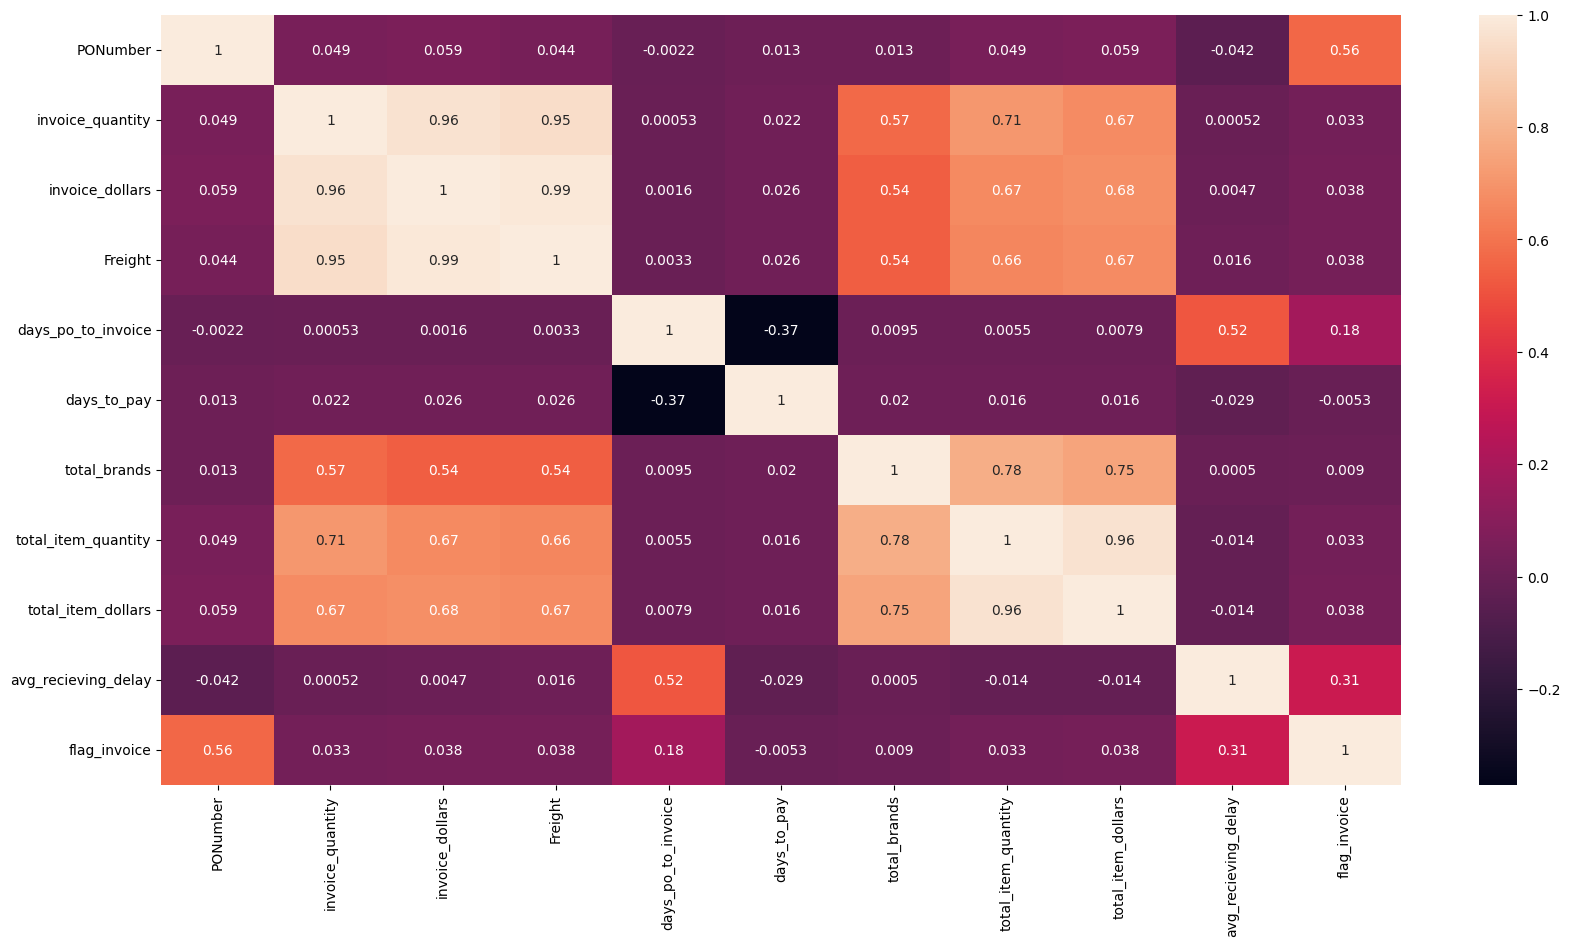

In [12]:
#defing the relation b/w the attriburtes
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [13]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [14]:
#hypothesis testing - needed to compare the significant diffrences between the 2 groups
significant_features=[]
non_significant_features=[]
results=[]

In [15]:
metrics = ['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','days_to_pay','total_brands','total_item_quantity'
,'days_to_pay','total_brands','total_item_quantity','total_item_dollars','avg_recieving_delay']


In [16]:
from scipy.stats import ttest_ind 
for metric in metrics:
  flagged_mean=flagged[metric].mean()
  normal_mean=normal[metric].mean()

  t_stat, p_value = ttest_ind(
      flagged[metric].dropna(),
      normal[metric].dropna(),
      equal_var=False
  )

  if p_value < 0.05:
    significant_features.append(metric)
    results.append({
        "metric":metric,
        "flagged_mean":flagged_mean.round(2),
        "normal_mean":normal_mean.round(2),
        "p_value":p_value.round(3)
    })
  else:
    non_significant_features.append(metric)


In [17]:
non_significant_features

['days_to_pay', 'total_brands', 'days_to_pay', 'total_brands']

In [18]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_quantity',
 'total_item_dollars',
 'avg_recieving_delay']

In [19]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric'

In [23]:
X= df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars']]
y=df['flag_invoice']

In [24]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Now we are using the standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [27]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [28]:
def evaluate_model(model,X_test,y_test,model_name):
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  report = classification_report(y_test, y_pred)
  print(f"--- {model_name} ---")
  print(f"Accuracy: {accuracy:.2f}")
  print("Classification Report:")
  print(report)

In [29]:
evaluate_model(model1,X_test_scaled,y_test,"Logistic Regression")
evaluate_model(model2,X_test_scaled,y_test,"Decision Tree Classifier")
evaluate_model(model3,X_test_scaled,y_test,"Random Forest Classifier")

--- Logistic Regression ---
Accuracy: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109

--- Decision Tree Classifier ---
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

--- Random Forest Classifier ---
Accuracy: 0.88
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      

In [30]:
#now we are testing using the min-max scaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [31]:
evaluate_model(model1,X_test_scaled,y_test,"Logistic Regression")
evaluate_model(model2,X_test_scaled,y_test,"Decision Tree Classifier")
evaluate_model(model3,X_test_scaled,y_test,"Random Forest Classifier")


--- Logistic Regression ---
Accuracy: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109

--- Decision Tree Classifier ---
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       725
           1       0.74      0.71      0.73       384

    accuracy                           0.81      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

--- Random Forest Classifier ---
Accuracy: 0.87
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      

In [32]:
# we see almost no diffrences in both the scaler techniques
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [33]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': model3.feature_importances_}).sort_values('Importance', ascending=False)
feature_importance

,Feature,Importance
6,total_item_dollars,0.219487
4,total_item_quantity,0.176694
0,invoice_quantity,0.151379
1,invoice_dollars,0.151249
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [34]:
# we see that total_brands and days_po_to_invoice has the least importnace
# so we would remove them and see wheather removing them creates any diffrence or not 
X= df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y=df['flag_invoice']

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model3,X_test_scaled,y_test,"Random Forest Classifier")

--- Random Forest Classifier ---
Accuracy: 0.88
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      0.68      0.79       384

    accuracy                           0.88      1109
   macro avg       0.90      0.83      0.85      1109
weighted avg       0.88      0.88      0.87      1109



In [35]:
#we found no signnificant change
# so now we would move to the hyper parameter tuning
# there are 2 ways of doing it - grid_search_cv , random_search_cv

# in the grid we have to pass the expected parameters and the value that are expected
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[None,4,5,6],
    "min_samples_split":[2,3,5],
    "min_samples_leaf":[1,2,5],
    "criterion":["gini","entropy"]
}


In [36]:
# now we fit the grid_search_cv
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer,f1_score
#f1 score gives the baalance of the accuurcy and recall
rf=RandomForestClassifier(random_state=42,n_jobs=-1)

scorer=make_scorer(f1_score)
grid_search=GridSearchCV(estimator=rf,param_grid=param_grid,
                         scoring=scorer,cv=5,verbose=2,n_jobs=-1)

grid_search.fit(X_train_scaled,y_train)
evaluate_model(grid_search,X_test_scaled,y_test,"Random Forest Classifier")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   4.9s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   1.7s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   1.6s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=100; total time=   1.6s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=200; total time=   3.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=300; tot

In [37]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[709, 124],
       [ 16, 260]])